In [ ]:
#Primary Model
import os
from torch.utils.data import Dataset, DataLoader, random_split
import cv2
import torch
import numpy as np

# =========================
# DATASET
# =========================
TRAIN_IMG = "/kaggle/input/datasets/akshitmahajan07/doctamper-dataset/DocTamper Training/images"
TRAIN_MASK = "/kaggle/input/datasets/akshitmahajan07/doctamper-dataset/DocTamper Training/masks"

class DocTamperDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=224):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.size = size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.size, self.size))

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (self.size, self.size))

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

dataset = DocTamperDataset(TRAIN_IMG, TRAIN_MASK)

# =========================
# TRAIN / VALIDATION SPLIT
# =========================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print("Train:", len(train_ds), " Val:", len(val_ds))


# =========================
# MODEL SETUP
# =========================
!pip install segmentation-models-pytorch albumentations

import segmentation_models_pytorch as smp
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# =========================
# METRICS
# =========================
def dice_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


# =========================
# TRAINING + BEST MODEL SAVE
# =========================
EPOCHS = 15
best_iou = 0

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    train_loss = 0

    loop = tqdm(train_loader)

    for images, masks in loop:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    # ---- VALIDATION ----
    model.eval()
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = model(images)

            val_iou += iou_score(preds, masks)
            val_dice += dice_score(preds, masks)

    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", train_loss/len(train_loader))
    print("Val IoU:", val_iou.item())
    print("Val Dice:", val_dice.item())

    # ---- SAVE BEST MODEL ----
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "/kaggle/working/unet_best.pth")
        print("Best model saved!")

In [10]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.5 MB/s eta 0:00:00


In [ ]:
#Second Iteration

import os
from torch.utils.data import Dataset, DataLoader, random_split
import cv2
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# =========================
# AUGMENTATIONS (BIG BOOST)
# =========================
train_transform = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224,224),
    ToTensorV2()
])

# =========================
# DATASET
# =========================
TRAIN_IMG = "/kaggle/input/datasets/akshitmahajan07/doctamper-dataset/DocTamper Training/images"
TRAIN_MASK = "/kaggle/input/datasets/akshitmahajan07/doctamper-dataset/DocTamper Training/masks"

class DocTamperDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0).float()/255.0

        return image.float()/255.0, mask

# =========================
# SPLIT
# =========================
dataset = DocTamperDataset(TRAIN_IMG, TRAIN_MASK, transform=train_transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_ds.dataset.transform = train_transform
val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

# =========================
# MODEL
# =========================

import segmentation_models_pytorch as smp
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

# HYBRID LOSS (IMPORTANT)
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = torch.nn.BCEWithLogitsLoss()

def hybrid_loss(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# LR scheduler (boost convergence)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5
)

# =========================
# METRICS
# =========================
def dice_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# =========================
# TRAINING
# =========================
EPOCHS = 10
best_iou = 0

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0
    
    loop = tqdm(train_loader)
    
    for images, masks in loop:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        preds = model(images)
        loss = hybrid_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    # VALIDATE
    model.eval()
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            preds = model(images)

            val_iou += iou_score(preds, masks)
            val_dice += dice_score(preds, masks)

    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    scheduler.step(val_iou)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", train_loss/len(train_loader))
    print("Val IoU:", val_iou.item())
    print("Val Dice:", val_dice.item())
    
    # SAVE MODEL EVERY EPOCH
    torch.save(model.state_dict(), "/kaggle/working/unet_last.pth")
    
    # SAVE BEST MODEL
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "/kaggle/working/unet_best.pth")
        print("Best model improved & saved.")




#After this code is done we need to run the codes below to generate test reports for evaluation 

/tmp/ipykernel_56/1325570523.py:20: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was u

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch [1/10]: 100%|██████████| 12000/12000 [24:15<00:00,  8.24it/s, loss=0.56] 



Epoch 1
Train Loss: 0.8595831418409944
Val IoU: 0.1964634358882904
Val Dice: 0.3145804703235626
Best model improved & saved.


Epoch [2/10]:  27%|██▋       | 3278/12000 [05:30<14:17, 10.17it/s, loss=0.928]

In [8]:
import os
print(os.listdir("/kaggle/working"))

['model.zip', 'unet_best.pth', '.virtual_documents', 'unet_last.pth']


Test samples: 30000


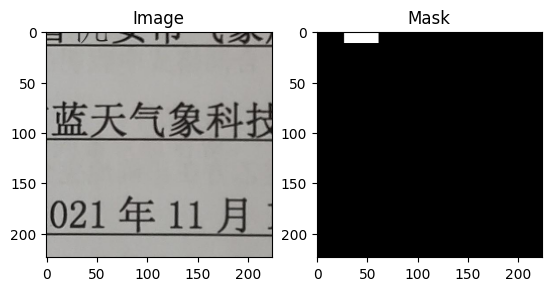

In [12]:
import os
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TEST_IMG = "/kaggle/input/datasets/akshitmahajan07/doctamper-dataset/DocTamper Testing/images"
TEST_MASK = "/kaggle/input/datasets/akshitmahajan07/doctamper-dataset/DocTamper Testing/masks"

class DocTamperTestDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=224):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.size = size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.size, self.size)) / 255.0

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (self.size, self.size)) / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

test_dataset = DocTamperTestDataset(TEST_IMG, TEST_MASK)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Test samples:", len(test_dataset))

img, mask = test_dataset[0]

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")

plt.show()


In [10]:
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(DEVICE)

model.load_state_dict(torch.load("/kaggle/working/unet_best.pth"))
model.eval()

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

In [12]:
def dice_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

In [13]:
test_ious = []
test_dices = []

with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)

        for i in range(len(images)):
            iou = iou_score(preds[i], masks[i])
            dice = dice_score(preds[i], masks[i])

            test_ious.append(iou.item())
            test_dices.append(dice.item())

avg_iou = np.mean(test_ious)
avg_dice = np.mean(test_dices)

print("\n===== TEST REPORT =====")
print("Average IoU:", avg_iou)
print("Average Dice:", avg_dice)

100%|██████████| 3750/3750 [15:05<00:00,  4.14it/s]


===== TEST REPORT =====
Average IoU: 0.2629567256796033
Average Dice: 0.31785127843537786


In [14]:
report_df = pd.DataFrame({
    "IoU": test_ious,
    "Dice": test_dices
})

report_df.to_csv("/kaggle/working/test_report.csv", index=False)

print("Detailed test report saved.")

Detailed test report saved.


100%|██████████| 3750/3750 [07:30<00:00,  8.32it/s]



===== TEST RESULTS =====
Average IoU: 0.2629567256796033
Average Dice: 0.31785127843537786


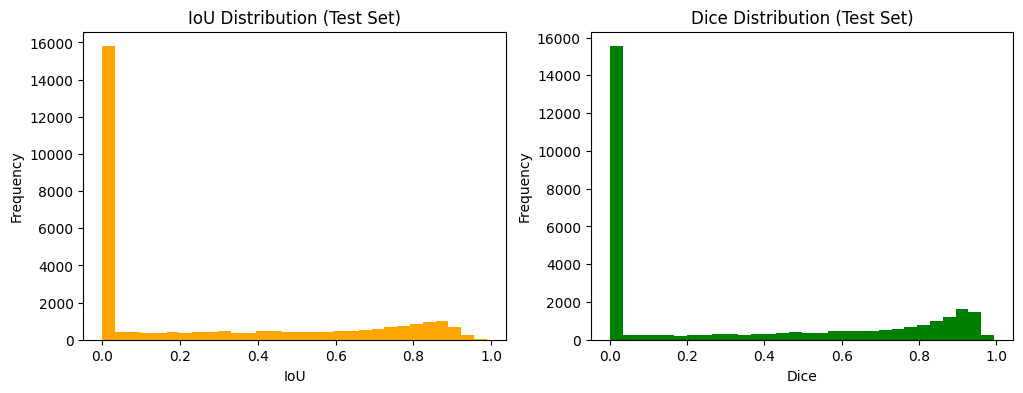

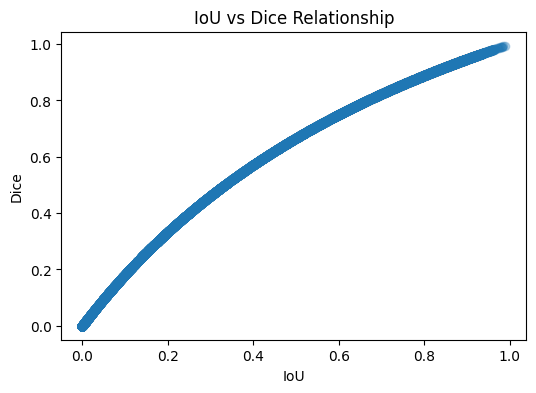

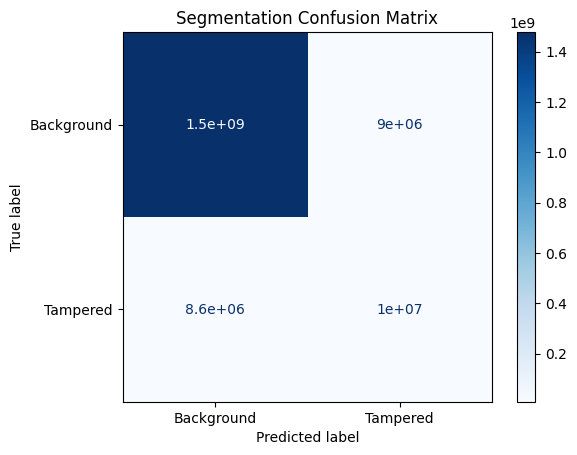

Graphs + confusion matrix saved to /kaggle/working/


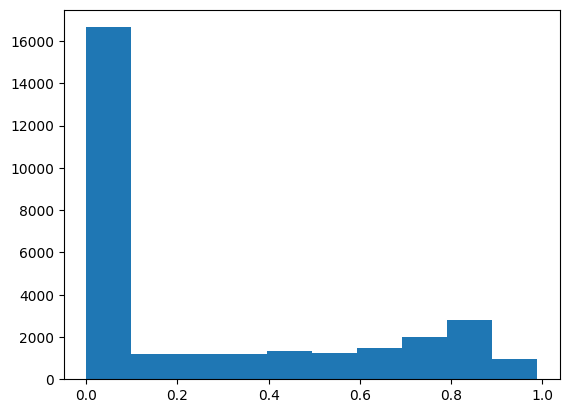

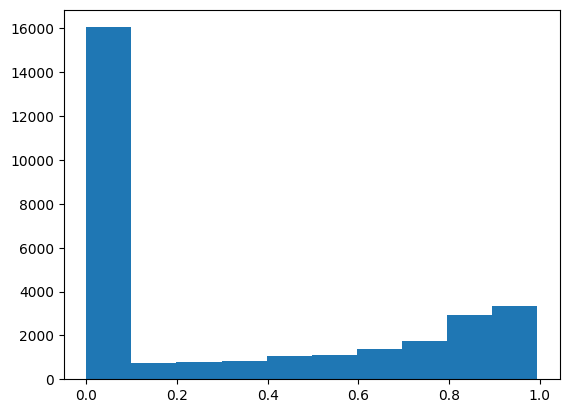

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

# ========================
# STORAGE
# ========================
test_ious = []
test_dices = []

# running confusion matrix (memory safe)
cm_total = np.zeros((2,2), dtype=np.int64)

# ========================
# EVALUATION LOOP
# ========================
model.eval()

with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)
        probs = torch.sigmoid(preds)
        preds_bin = (probs > 0.5).float()

        # ---- metrics per image ----
        for i in range(len(images)):
            iou = iou_score(preds[i], masks[i])
            dice = dice_score(preds[i], masks[i])
            test_ious.append(iou.item())
            test_dices.append(dice.item())

        # ---- FIXED confusion matrix block (memory safe + binary masks) ----
        preds_flat = preds_bin.cpu().numpy().reshape(-1)

        masks_bin = (masks > 0.5).float()
        masks_flat = masks_bin.cpu().numpy().reshape(-1)

        cm_total += confusion_matrix(
            masks_flat,
            preds_flat,
            labels=[0,1]
        )

# ========================
# FINAL METRICS
# ========================
avg_iou = np.mean(test_ious)
avg_dice = np.mean(test_dices)

print("\n===== TEST RESULTS =====")
print("Average IoU:", avg_iou)
print("Average Dice:", avg_dice)

# ========================
# GRAPH 1 — IoU distribution
# ========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(test_ious, bins=30, color="orange")
plt.title("IoU Distribution (Test Set)")
plt.xlabel("IoU")
plt.ylabel("Frequency")

# ========================
# GRAPH 2 — Dice distribution
# ========================
plt.subplot(1,2,2)
plt.hist(test_dices, bins=30, color="green")
plt.title("Dice Distribution (Test Set)")
plt.xlabel("Dice")
plt.ylabel("Frequency")

plt.show()

# ========================
# GRAPH 3 — IoU vs Dice scatter
# ========================
plt.figure(figsize=(6,4))
plt.scatter(test_ious, test_dices, alpha=0.3)
plt.title("IoU vs Dice Relationship")
plt.xlabel("IoU")
plt.ylabel("Dice")
plt.show()

# ========================
# CONFUSION MATRIX
# ========================
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_total,
    display_labels=["Background","Tampered"]
)
disp.plot(cmap="Blues")
plt.title("Segmentation Confusion Matrix")
plt.show()

# ========================
# SAVE OUTPUTS
# ========================
plt.figure()
plt.hist(test_ious)
plt.savefig("/kaggle/working/iou_distribution.png")

plt.figure()
plt.hist(test_dices)
plt.savefig("/kaggle/working/dice_distribution.png")

np.save("/kaggle/working/confusion_matrix.npy", cm_total)

print("Graphs + confusion matrix saved to /kaggle/working/")

In [8]:
import matplotlib.pyplot as plt

dataset = DocTamperDataset(TRAIN_IMG, TRAIN_MASK, transform=val_transform)

img, mask = dataset[0]

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")

plt.show()


NameError: name 'DocTamperDataset' is not defined